### Imports

In [1]:
import os
import time
import copy
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import sys

print(f"Python: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")

# Configurando o device (GPU se disponível, senão CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Python: d:\venvs\VisaoComputacional\Scripts\python.exe
PyTorch: 2.12.0+cu126
CUDA disponível: True
Dispositivo em uso: cuda:0


### Transformações e Carregamento de Dados

In [2]:
base_dir = '../../chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_base_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['val']) 
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

# Split (80% Treino / 20% Validação)
targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(val_base_dataset, val_idx)

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_subset), 'val': len(val_subset)}

print(f"Treino: {dataset_sizes['train']} imagens | Validação: {dataset_sizes['val']} imagens")
print(f"Classes: {full_train_dataset.class_to_idx}")

Treino: 4185 imagens | Validação: 1047 imagens
Classes: {'NORMAL': 0, 'PNEUMONIA_BACTERIAL': 1, 'PNEUMONIA_VIRAL': 2}


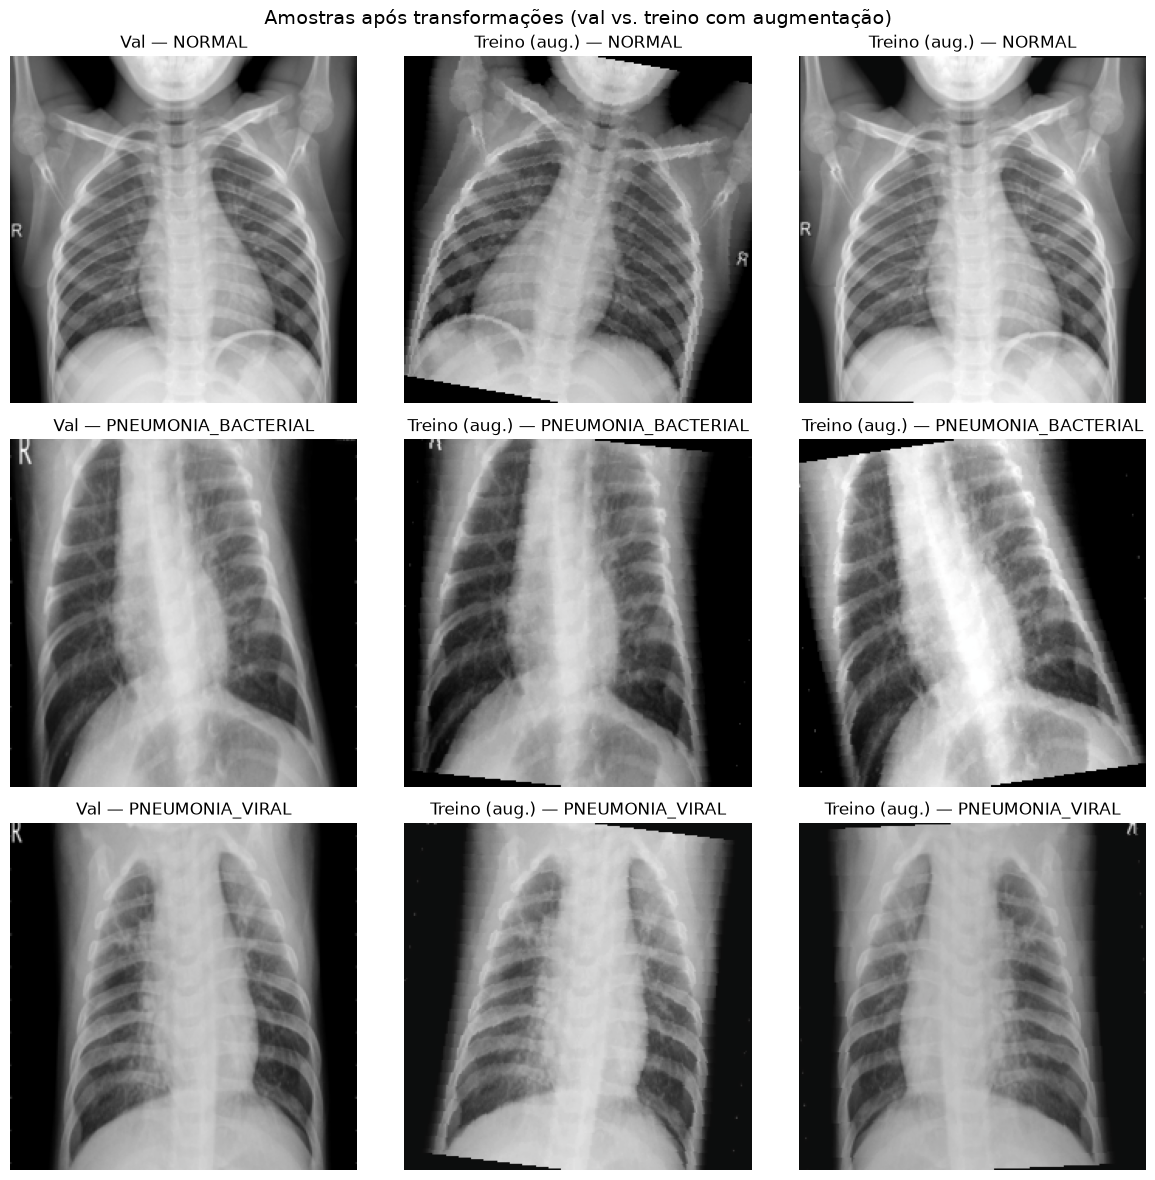

In [3]:
# Visualização de imagens após as transformações
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
class_names = full_train_dataset.classes

def tensor_to_display(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

# Uma amostra de cada classe
indices_by_class = {}
for idx in train_idx:
    label = targets[idx]
    if label not in indices_by_class:
        indices_by_class[label] = idx

fig, axes = plt.subplots(len(class_names), 3, figsize=(12, 4 * len(class_names)))
for row, class_id in enumerate(sorted(indices_by_class.keys())):
    idx = indices_by_class[class_id]
    name = class_names[class_id]

    val_img, _ = val_base_dataset[idx]
    axes[row, 0].imshow(tensor_to_display(val_img), cmap='gray')
    axes[row, 0].set_title(f'Val — {name}')
    axes[row, 0].axis('off')

    for col in range(1, 3):
        train_img, _ = full_train_dataset[idx]
        axes[row, col].imshow(tensor_to_display(train_img), cmap='gray')
        axes[row, col].set_title(f'Treino (aug.) — {name}')
        axes[row, col].axis('off')

plt.suptitle('Amostras após transformações (val vs. treino com augmentação)', fontsize=14)
plt.tight_layout()
plt.show()

### Cálculo de Pesos das Classes

In [ ]:
# Contagem de classes no conjunto de treino
train_classes = [targets[i] for i in train_idx]
class_counts = Counter(train_classes)
num_classes = len(class_names)
total_samples = len(train_classes)

base_weights_list = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]

# Multiplicador de Risco Clínico [NORMAL, BACTERIANA, VIRAL]
penalidade_clinica = [1.0, 3.0, 3.0] 
final_weights = [base * pen for base, pen in zip(base_weights_list, penalidade_clinica)]
class_weights = torch.FloatTensor(final_weights).to(device)

print(f"Pesos Finais da V3: {class_weights.cpu().numpy()}")

# A função de perda deve receber estes novos pesos
criterion = nn.CrossEntropyLoss(weight=class_weights)

Pesos Finais da V3: [1.2928637 2.0615764 3.8894053]


### Construção do Modelo DenseNet121

In [5]:
def create_densenet_model_V3(num_classes=3, freeze_features=True):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False
            
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

model_cnn_V3 = create_densenet_model_V3().to(device)

# A Loss recebe os pesos penalizados
criterion = nn.CrossEntropyLoss(weight=class_weights) 
optimizer = optim.Adam(model_cnn_V3.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Modelo DenseNet121_V3, Critério e Otimizador inicializados com sucesso.")

Modelo DenseNet121_V3, Critério e Otimizador inicializados com sucesso.


### Loop de Treinamento e Validação

In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            
            progress_bar = tqdm(dataloaders[phase], 
                                desc=f"{phase.capitalize()} Epoch {epoch+1}", 
                                leave=False)

            # Iterando sobre os dados usando a barra de progresso
            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Otimização apenas se estiver no treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Atualiza a barra de progresso com a Loss do lote atual em tempo real
                progress_bar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

            # Calcula a média da Loss e Acurácia ao final da época
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                
            # Salva o modelo se a acurácia de validação for a melhor até agora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print() # Linha em branco para separar as épocas visualmente

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    # Carrega os melhores pesos antes de retornar o modelo
    model.load_state_dict(best_model_wts)
    return model

### Execução do Treinamento

In [ ]:
# Inicia o treinamento
model_cnn_V3 = train_model(model_cnn_V3, criterion, optimizer, scheduler, num_epochs=10)

# Salva o modelo treinado para uso futuro
torch.save(model_cnn_V3.state_dict(), 'densenetV3_pneumonia_best.pth')
print("Pesos do modelo salvos em 'densenetV3_pneumonia_best.pth'")

Época 1/10
----------


Train Epoch 1:   0%|          | 0/131 [00:07<?, ?it/s]

Train - Loss: 0.8848 Acc: 0.5384


Val Epoch 1:   0%|          | 0/33 [00:20<?, ?it/s]

Val - Loss: 0.6982 Acc: 0.7077

Época 2/10
----------


...

Val - Loss: 0.6187 Acc: 0.7631

Época 10/10
----------


Train Epoch 10:   0%|          | 0/131 [00:07<?, ?it/s]

Train - Loss: 0.7227 Acc: 0.6703


Val Epoch 10:   0%|          | 0/33 [00:07<?, ?it/s]

Val - Loss: 0.6448 Acc: 0.7746

Treinamento completo em 18m 1s
Melhor Acurácia de Validação: 0.7746
Pesos do modelo salvos em 'densenetV3_pneumonia_best.pth'


### Inferência no Conjunto de Teste e Métricas Principais

In [8]:
class_names = full_train_dataset.classes

caminho_pesos = 'densenetV3_pneumonia_best.pth'

if os.path.exists(caminho_pesos):
    # O map_location=device garante que funcione com GPU ou CPU
    model_cnn_V3.load_state_dict(torch.load(caminho_pesos, map_location=device))
    
    # Coloca o modelo em modo de avaliação (desativa dropout, etc.)
    model_cnn_V3.eval() 

def evaluate_clinical_model(model, test_loader, normal_threshold=0.70):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Avaliação Clínica", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Extrai probabilidades de 0.0 a 1.0
            probs = torch.softmax(outputs, dim=1)
            
            preds = []
            for p in probs:
                prob_normal = p[0].item()
                prob_bact = p[1].item()
                prob_viral = p[2].item()
                
                if prob_normal >= normal_threshold:
                    preds.append(0) # Normal
                else:
                    if prob_bact > prob_viral:
                        preds.append(1) # Bacteriana
                    else:
                        preds.append(2) # Viral
                        
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)
            
    return y_true, y_pred

# Executa a avaliação e guarda os resultados
y_true_V3, y_pred_V3 = evaluate_clinical_model(model_cnn_V3, test_loader, normal_threshold=0.70)

Avaliação Clínica:   0%|          | 0/20 [00:01<?, ?it/s]

### Matriz de Confusão

--- RELATÓRIO CLÍNICO V3 ---
                     precision    recall  f1-score   support

             NORMAL       0.95      0.33      0.49       234
PNEUMONIA_BACTERIAL       0.67      0.96      0.79       242
    PNEUMONIA_VIRAL       0.56      0.74      0.64       148

           accuracy                           0.67       624
          macro avg       0.73      0.68      0.64       624
       weighted avg       0.75      0.67      0.64       624



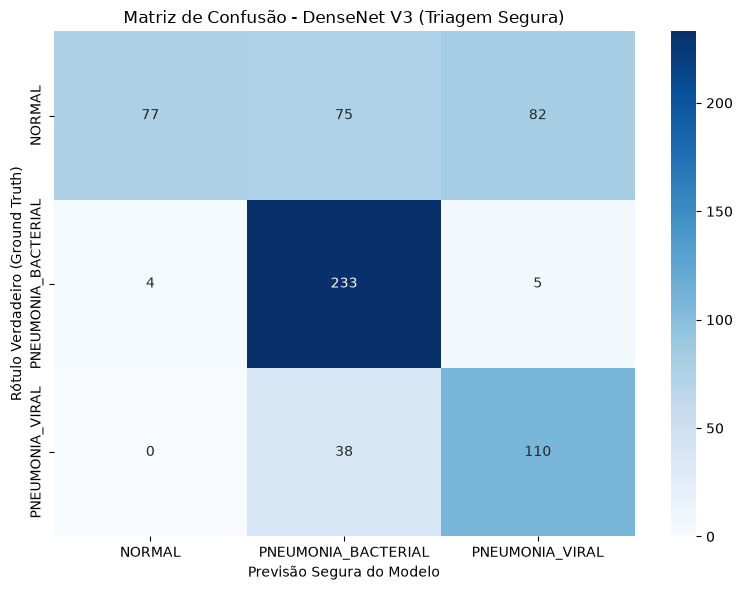

In [9]:
print(f"--- RELATÓRIO CLÍNICO V3 ---")
print(classification_report(y_true_V3, y_pred_V3, target_names=class_names))

cm = confusion_matrix(y_true_V3, y_pred_V3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - DenseNet V3 (Triagem Segura)')
plt.ylabel('Rótulo Verdadeiro (Ground Truth)')
plt.xlabel('Previsão Segura do Modelo')
plt.tight_layout()
plt.show()

### Inspeção Visual das Previsões

Amostra de Previsões no Conjunto de Teste:


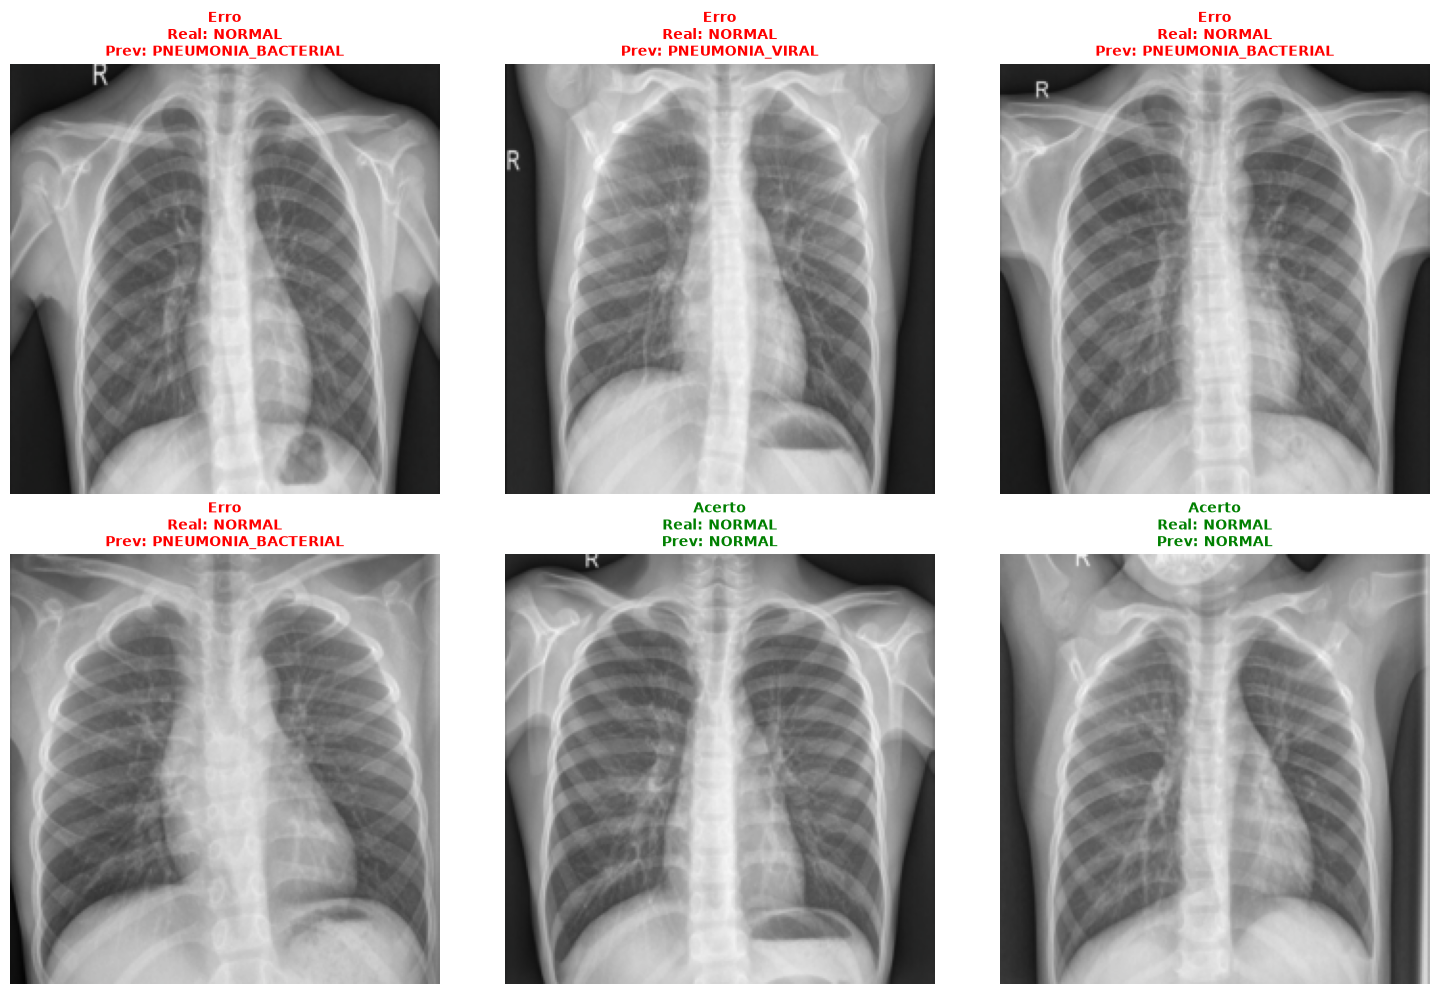

In [10]:
def imshow_unnormalized(inp, title=None):
    """Reverte a normalização do ImageNet para exibição visual."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10, fontweight='bold', color='green' if 'Acerto' in title else 'red')
    plt.axis('off')

def visualize_predictions(model, test_loader, class_names, num_images=6):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, num_images // 2, images_so_far)
                
                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]
                
                status = "Acerto" if true_label == pred_label else "Erro"
                title = f"{status}\nReal: {true_label}\nPrev: {pred_label}"
                
                imshow_unnormalized(inputs.cpu().data[j], title)
                
                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

# Plota um grid com 6 imagens do conjunto de teste e suas classificações
print("Amostra de Previsões no Conjunto de Teste:")
visualize_predictions(model_cnn_V3, test_loader, class_names, num_images=6)

### Grad-CAM — Mapas de Calor


A gerar mapas de calor Grad-CAM...


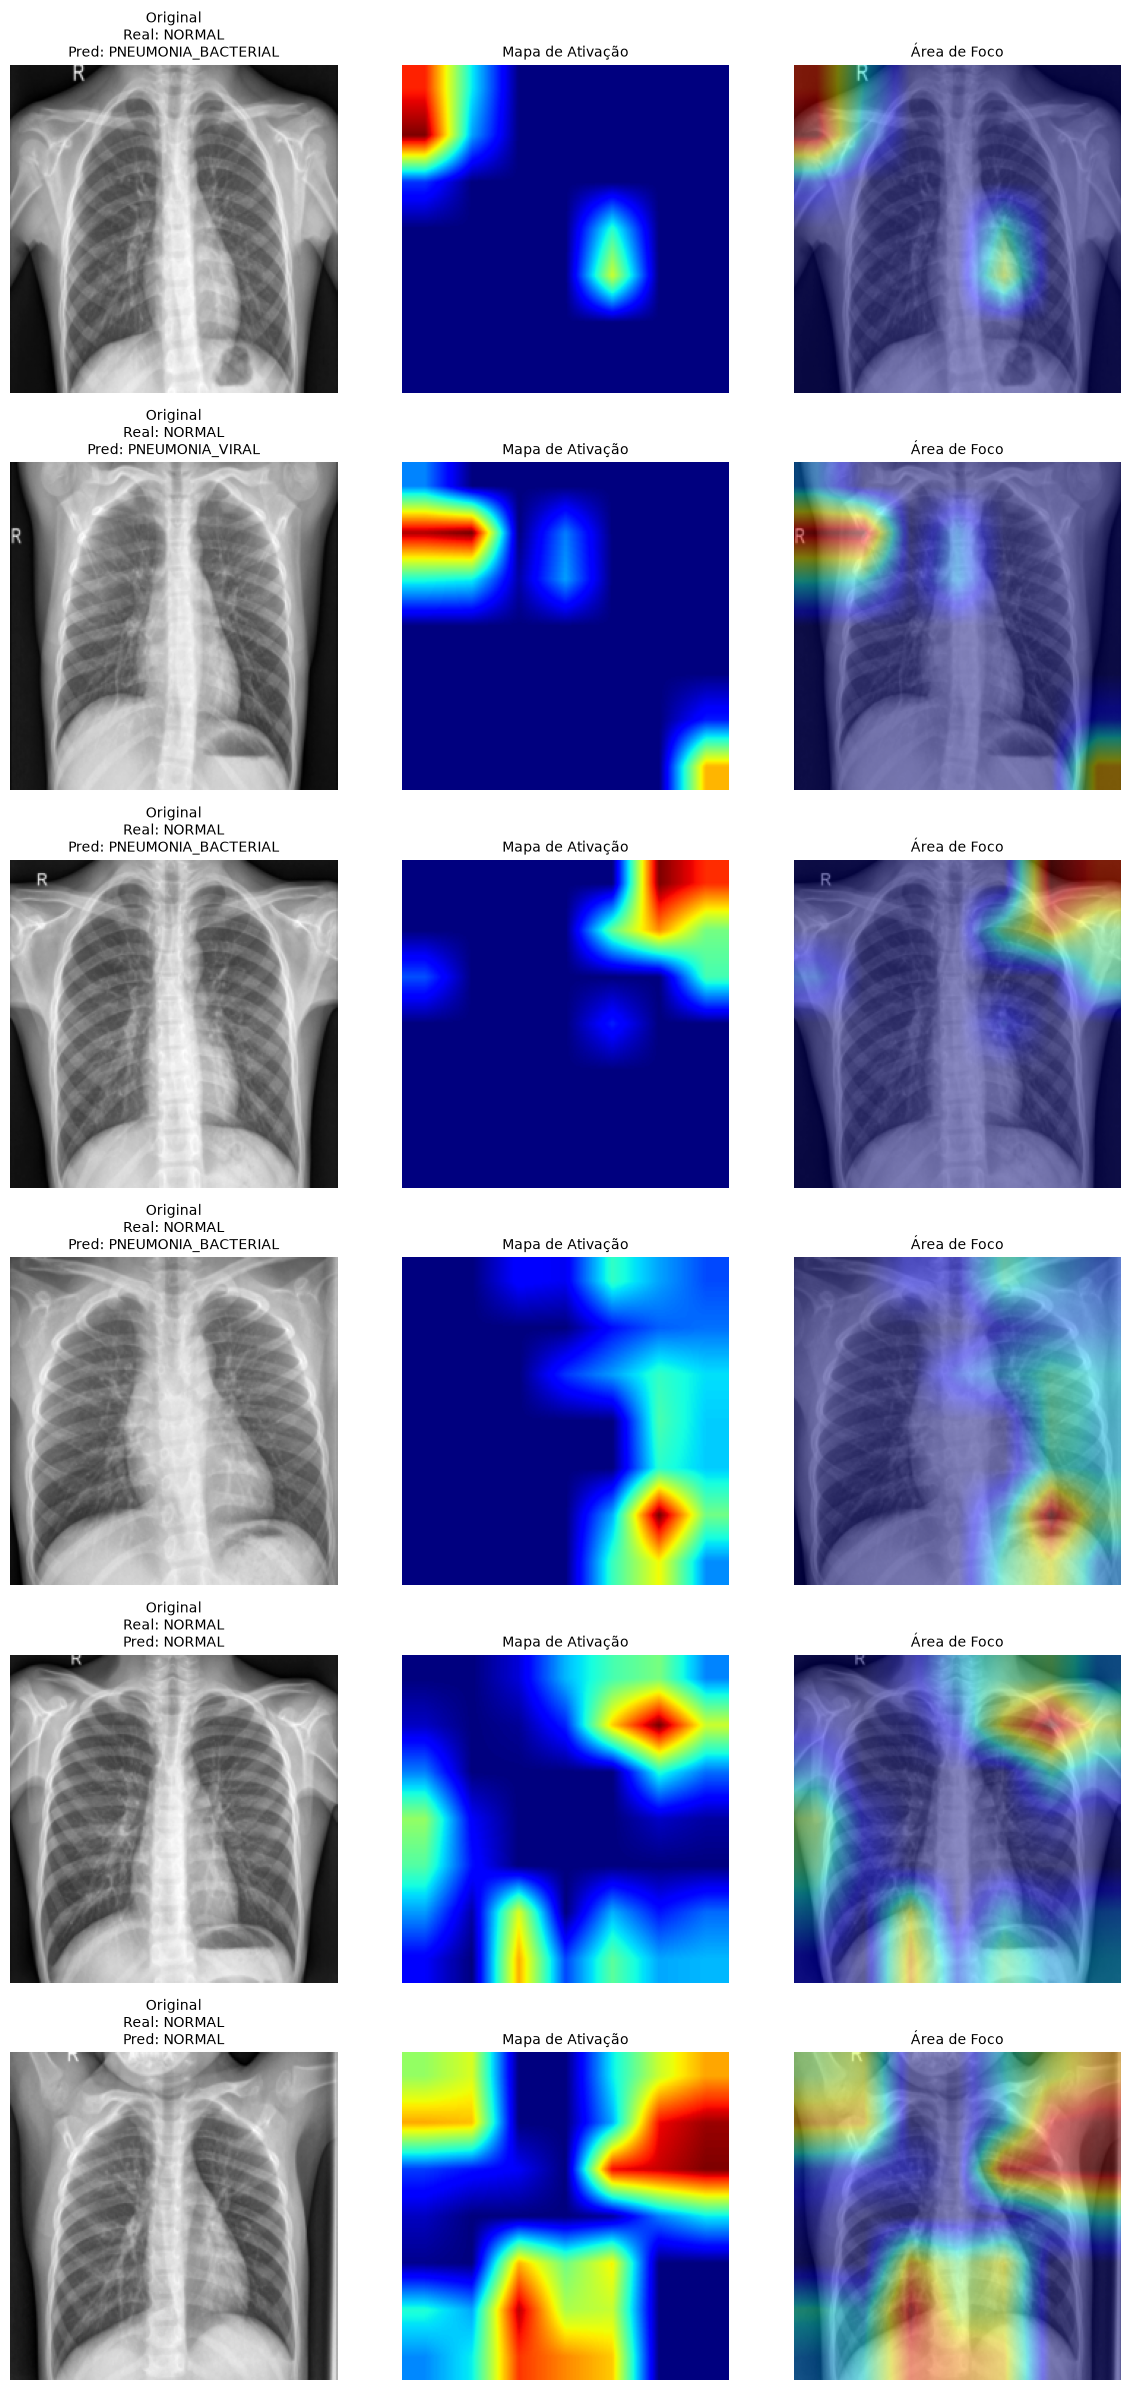

In [ ]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class DenseNetGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        
        # Desativar operações 'inplace' para evitar o erro de view/memória do PyTorch
        for module in self.model.modules():
            if hasattr(module, 'inplace'):
                module.inplace = False

        # Registar hooks simples
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()
        
        input_tensor.requires_grad_(True)

        logits = self.model(input_tensor)

        if target_class is None:
            target_class = logits.argmax(dim=1).item()

        score = logits[0, target_class]
        score.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM falhou: gradientes não capturados.")

        # Matemática do Grad-CAM
        activations = self.activations.detach()
        gradients = self.gradients.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1).squeeze()
        cam = F.relu(cam)

        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)
        
        return cam, target_class

def tensor_to_rgb(tensor):
    image = tensor.detach().cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    return image

def visualize_gradcam(model, test_loader, class_names, num_images=6):
    print("\nA gerar mapas de calor Grad-CAM...")
    
    target_layer = model.features.denseblock4.denselayer16.conv2
    cam_extractor = DenseNetGradCAM(model, target_layer)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    images_shown = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()

        for i in range(inputs.size(0)):
            if images_shown >= num_images:
                break

            img_tensor = inputs[i].unsqueeze(0)
            true_label = labels[i]

            cam, pred_label = cam_extractor.generate_cam(img_tensor)
            title = f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]}"

            gray = tensor_to_rgb(img_tensor[0]).mean(axis=2)
            row = axes[images_shown]

            row[0].imshow(gray, cmap='gray')
            row[0].set_title(f'Original\n{title}', fontsize=10)
            row[0].axis('off')

            row[1].imshow(cam, cmap='jet')
            row[1].set_title('Mapa de Ativação', fontsize=10)
            row[1].axis('off')

            row[2].imshow(gray, cmap='gray')
            row[2].imshow(cam, cmap='jet', alpha=0.45)
            row[2].set_title('Área de Foco', fontsize=10)
            row[2].axis('off')

            images_shown += 1

        if images_shown >= num_images:
            break

    plt.tight_layout()
    plt.show()

# Chama a função visual
visualize_gradcam(model_cnn_V3, test_loader, class_names, num_images=6)